# EDA: классификация ботов

Цель ноутбука это понять, чем поведение ботов отличается от людей, и выбрать признаки для `quickstart.ipynb`.

Все поведенческие расчёты используют только события внутри окна: `window_start_ts <= event_ts < window_end_ts`.

Важно: `target` доступен только для train. Target-агрегаты из категорий нельзя переносить в модель без out-of-fold схемы.

In [1]:
from pathlib import Path
import os
import re
import numpy as np
import pandas as pd

PLOT_CACHE_DIR = Path('artifacts/mplconfig')
PLOT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(PLOT_CACHE_DIR.resolve()))
import matplotlib.pyplot as plt
from IPython.display import display

CANDIDATES = [Path('/kaggle/input/avito-bootcamp-fall'), Path('/kaggle/input'), Path('.')]
DATA_DIR = next((p for p in CANDIDATES if (p / 'data/train.csv').exists()), Path('.'))


def data_path(name):
    p = DATA_DIR / name
    return p if p.exists() else DATA_DIR / 'data' / name


train = pd.read_csv(data_path('train.csv'), parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv(data_path('test.csv'), parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv(data_path('events.csv.gz'), parse_dates=['event_ts'])
print(f'train={train.shape}, test={test.shape}, events={events.shape}')
print(f'Доля ботов: {train.target.mean():.3%}')

train=(11091, 5), test=(4909, 4), events=(328905, 14)
Доля ботов: 8.106%


## 1. Качество данных и временная структура

In [2]:
display(train.head())
display(events.head())
print('Диапазон событий:', events.event_ts.min(), '—', events.event_ts.max())
print('Диапазон train окон:', train.window_start_ts.min(), '—', train.window_start_ts.max())
print('Диапазон test окон:', test.window_start_ts.min(), '—', test.window_start_ts.max())

quality = pd.DataFrame({
    'dtype': events.dtypes.astype(str),
    'missing_%': (events.isna().mean() * 100).round(2),
    'nunique': events.nunique(dropna=True),
}).sort_values('missing_%', ascending=False)
display(quality)
print('Полных дублей событий:', events.duplicated().sum())
print('Дубликатов по cookie_id + event_ts + eid:', events.duplicated(['cookie_id', 'event_ts', 'eid']).sum())

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


Диапазон событий: 2026-04-06 00:02:57 — 2026-04-26 23:59:50
Диапазон train окон: 2026-04-06 00:00:00 — 2026-04-19 00:00:00
Диапазон test окон: 2026-04-20 00:00:00 — 2026-04-26 00:00:00


,dtype,missing_%,nunique
search_query,str,69.47,120
search_page,float64,69.47,46
pointer_x,float64,67.00,1921
pointer_y,float64,67.00,1081
seller_type,str,40.70,2
item_id,float64,34.84,53856
item_category,str,10.01,15
item_location,str,7.23,40
cookie_id,str,0.00,16000
event_ts,datetime64[us],0.00,285094


Полных дублей событий: 4863
Дубликатов по cookie_id + event_ts + eid: 5270


In [3]:
for col in ['event_name', 'platform', 'item_category', 'item_location', 'seller_type']:
    print(f'\n{col}: {events[col].nunique(dropna=True)} уникальных')
    display(events[col].value_counts(dropna=False).head(20).to_frame('count'))

age = train.assign(cookie_age_days=(train.window_start_ts - train.cookie_created_at).dt.total_seconds() / 86400)
display(age[['cookie_age_days', 'window_start_ts', 'window_end_ts']].describe())


event_name: 10 уникальных


,count
event_name,
item_view,120817
search_results_view,100402
photo_swipe,36517
favorite_add,19049
seller_page_view,17403
contact_phone_show,11316
captcha_shown,7928
login,6267
contact_chat_open,6125



platform: 11 уникальных


,count
platform,
desktop,46866
WEB,46476
Web,46365
web,45951
ANDROID,42462
Android,42254
android,42159
iphone,4103
IOS,4100



item_category: 15 уникальных


...


item_location: 40 уникальных


,count
item_location,
sankt-peterburg,39221
novosibirsk,37989
moskva,37964
ekaterinburg,37281
NaN,23793
ryazan,4627
izhevsk,4576
barnaul,4559
astrahan,4511



seller_type: 2 уникальных


,count
seller_type,
NaN,133853
private,112631
pro,82421


,cookie_age_days,window_start_ts,window_end_ts
count,11091.000000,11091,11091
mean,71.867225,2026-04-12 04:33:10.370570,2026-04-13 04:33:10.370570
min,0.012361,2026-04-06 00:00:00,2026-04-07 00:00:00
25%,13.114740,2026-04-09 00:00:00,2026-04-10 00:00:00
50%,59.759178,2026-04-12 00:00:00,2026-04-13 00:00:00
75%,108.552766,2026-04-15 00:00:00,2026-04-16 00:00:00
max,449.284873,2026-04-19 00:00:00,2026-04-20 00:00:00
std,66.993073,NaN,NaN


## 2. События строго внутри окна

In [4]:
def events_in_window(events, meta):
    x = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id', how='inner')
    return x.loc[(x.event_ts >= x.window_start_ts) & (x.event_ts < x.window_end_ts)].copy()


ev_train = events_in_window(events, train)
ev_test = events_in_window(events, test)
print('События в train/test окнах:', ev_train.shape, ev_test.shape)
print('Среднее событий на cookie:', len(ev_train) / len(train), len(ev_test) / len(test))

all_meta = pd.concat([train.assign(split='train'), test.assign(split='test')])
check = events.merge(all_meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
check['inside'] = check.event_ts.ge(check.window_start_ts) & check.event_ts.lt(check.window_end_ts)
display(check.groupby('inside').size().rename('events').to_frame())

События в train/test окнах: (198436, 16) (89690, 16)
Среднее событий на cookie: 17.89162383914886 18.270523528213484


,events
inside,
False,40779
True,288126


## 3. Интенсивность и ритм
Самое важное это часы активности людей и ботов

target                         0         1
events          median     12.00     20.00
                mean       16.87     29.48
unique_events   median      4.00      5.00
                mean        4.60      4.80
unique_items    median      6.00     10.00
                mean        8.92     13.78
active_hours    median      3.00      3.00
                mean        3.13      3.22
gap_mean        median    657.29    425.41
                mean      839.43    562.15
gap_median      median     59.00     25.00
                mean      219.33     99.97
span_sec        median   8326.50   9092.00
                mean    11621.67  12082.85
events_per_hour median      6.03      8.94
                mean       24.52     39.37

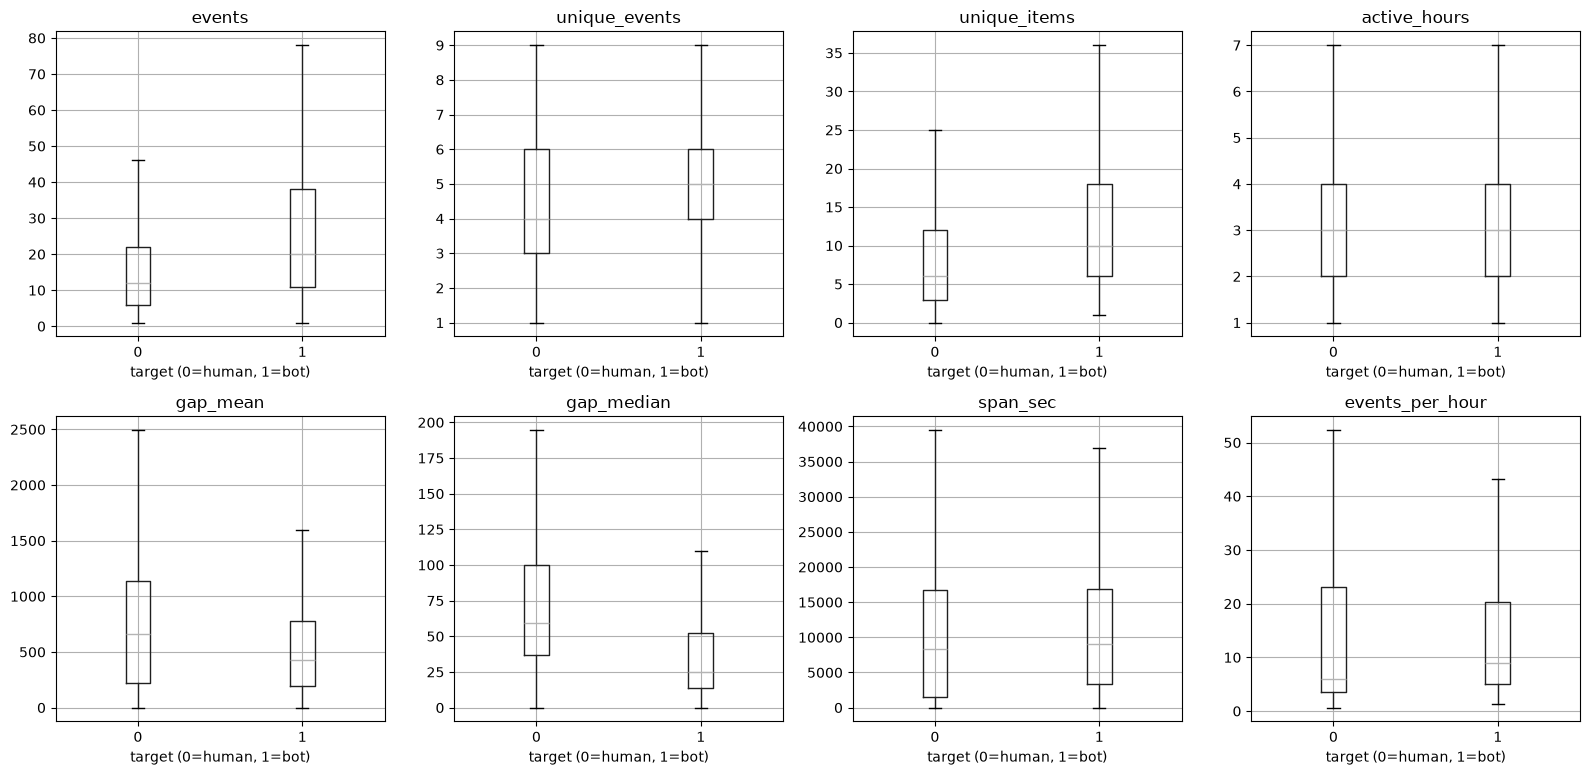

In [5]:
def cookie_basic_agg(ev):
    x = ev.sort_values(['cookie_id', 'event_ts']).copy()
    x['gap_sec'] = x.groupby('cookie_id').event_ts.diff().dt.total_seconds()
    x['hour'] = x.event_ts.dt.hour
    out = x.groupby('cookie_id').agg(
        events=('eid', 'size'),
        unique_events=('event_name', 'nunique'),
        unique_items=('item_id', 'nunique'),
        unique_categories=('item_category', 'nunique'),
        unique_locations=('item_location', 'nunique'),
        active_hours=('hour', 'nunique'),
        first_event=('event_ts', 'min'),
        last_event=('event_ts', 'max'),
        gap_mean=('gap_sec', 'mean'),
        gap_median=('gap_sec', 'median'),
        gap_min=('gap_sec', 'min'),
        gap_std=('gap_sec', 'std'))
    out['span_sec'] = (out.last_event - out.first_event).dt.total_seconds()
    out['events_per_hour'] = out.events / (out.span_sec / 3600).clip(lower=1 / 60)
    return out.reset_index()


basic = cookie_basic_agg(ev_train).merge(train[['cookie_id', 'target']], on='cookie_id')
cols = ['events', 'unique_events', 'unique_items', 'active_hours', 'gap_mean', 'gap_median', 'span_sec',
        'events_per_hour']
display(basic.groupby('target')[cols].agg(['median', 'mean']).T.round(2))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), cols):
    basic.boxplot(column=col, by='target', ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel('target (0=human, 1=bot)')
plt.suptitle('')
plt.tight_layout()

target,0,1
hour,,
0,0.0099,0.0254
1,0.0138,0.0312
2,0.0210,0.0428
3,0.0255,0.0558
4,0.0278,0.0399
5,0.0319,0.0476
6,0.0291,0.0363
7,0.0320,0.0401
8,0.0330,0.0458


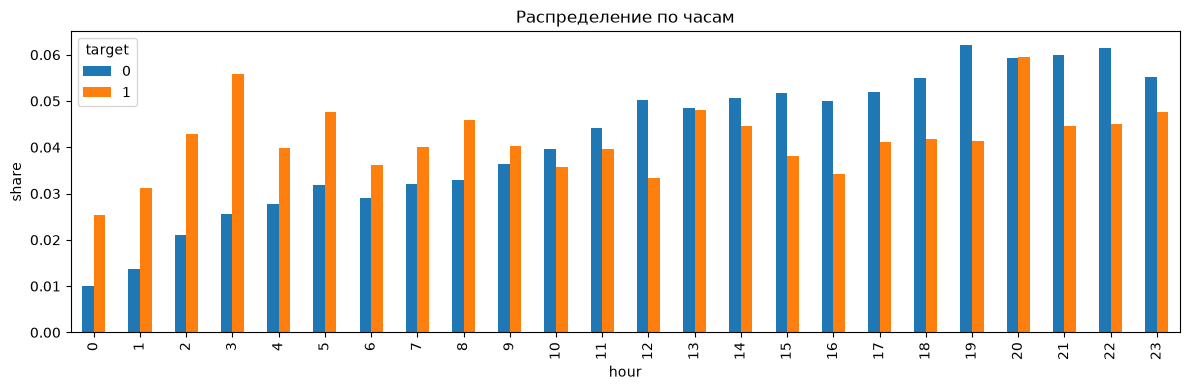

target,0,1
gap_bin,,
"(-1.0, 0.0]",0.0219,0.0171
"(0.0, 1.0]",0.0111,0.0039
"(1.0, 5.0]",0.0453,0.1426
"(5.0, 30.0]",0.2924,0.5614
"(30.0, 300.0]",0.4773,0.1710
"(300.0, 1800.0]",0.0290,0.0344
"(1800.0, 3600.0]",0.0317,0.0168
"(3600.0, inf]",0.0913,0.0529


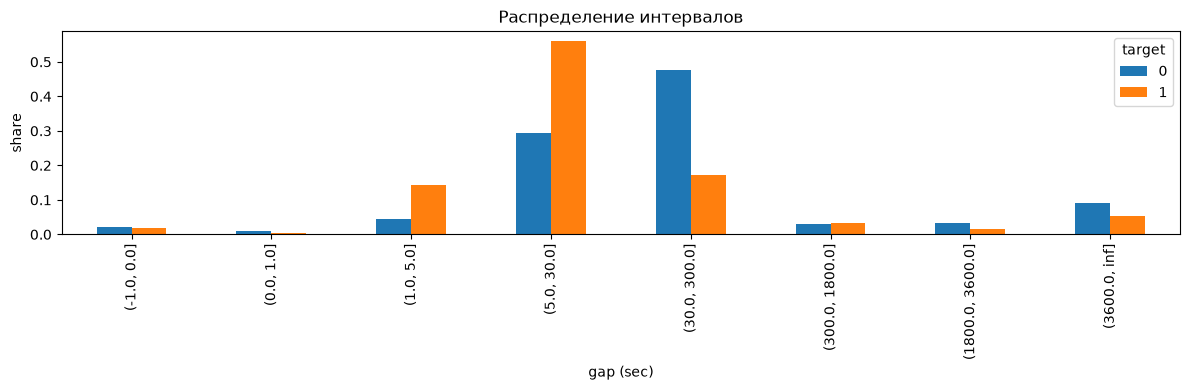

In [6]:
hour_target = ev_train.assign(hour=ev_train.event_ts.dt.hour).merge(train[['cookie_id', 'target']], on='cookie_id')
hour_target = hour_target.groupby(['target', 'hour']).size().rename('events').reset_index()
hour_target['share'] = hour_target.events / hour_target.groupby('target').events.transform('sum')
display(hour_target.pivot(index='hour', columns='target', values='share').fillna(0).round(4))

p = hour_target.pivot(index='hour', columns='target', values='share').fillna(0)
p = p.reindex(range(24), fill_value=0)

p.plot(kind='bar', figsize=(12, 4))
plt.xlabel('hour')
plt.ylabel('share')
plt.title('Распределение по часам')
plt.tight_layout()
plt.show()

gaps = ev_train.sort_values(['cookie_id', 'event_ts']).copy()
gaps['gap_sec'] = gaps.groupby('cookie_id').event_ts.diff().dt.total_seconds()
gaps = gaps.merge(train[['cookie_id', 'target']], on='cookie_id')
gaps['gap_bin'] = pd.cut(gaps.gap_sec, [-1, 0, 1, 5, 30, 300, 1800, 3600, np.inf])
gap_dist = gaps.groupby(['target', 'gap_bin'], observed=False).size().rename('n').reset_index()
gap_dist['share'] = gap_dist.n / gap_dist.groupby('target').n.transform('sum')
display(gap_dist.pivot(index='gap_bin', columns='target', values='share').fillna(0).round(4))

g = gap_dist.pivot(index='gap_bin', columns='target', values='share').fillna(0)
g.index = g.index.astype(str)

g.plot(kind='bar', figsize=(12, 4))
plt.xlabel('gap (sec)')
plt.ylabel('share')
plt.title('Распределение интервалов')
plt.tight_layout()
plt.show()

## 4. Состав событий и последовательности

target,0,1
event_name,,
item_view,0.3651,0.4364
search_results_view,0.3048,0.3515
photo_swipe,0.1227,0.0702
seller_page_view,0.0531,0.0590
favorite_add,0.0658,0.0272
contact_phone_show,0.0370,0.0258
contact_chat_open,0.0198,0.0142
contact_message_sent,0.0103,0.0079
login,0.0215,0.0078


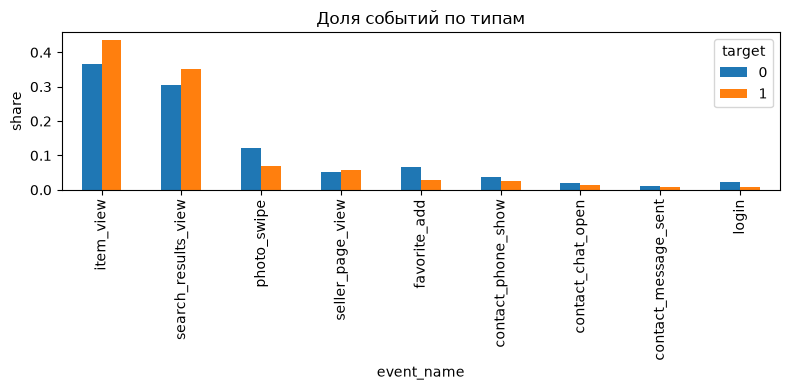

target,0,1
item_view,0.3571,0.4286
search_results_view,0.3000,0.3333
photo_swipe,0.1111,0.0625
seller_page_view,0.0000,0.0500
contact_chat_open,0.0000,0.0000
contact_message_sent,0.0000,0.0000
contact_phone_show,0.0000,0.0000
favorite_add,0.0400,0.0000
login,0.0000,0.0000


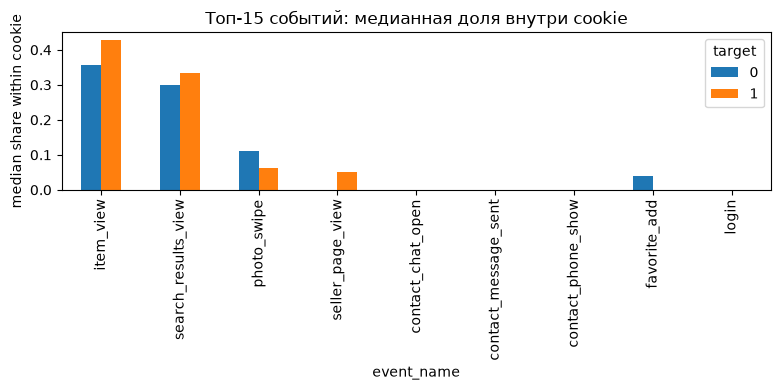

count
event_name          next_event                
item_view           item_view            27340
search_results_view item_view            21806
item_view           search_results_view  21732
search_results_view search_results_view  18915
item_view           photo_swipe           7899
photo_swipe         item_view             7676
                    search_results_view   6580
search_results_view photo_swipe           6431
favorite_add        item_view             4063
item_view           favorite_add          3971
seller_page_view    item_view             3754
item_view           seller_page_view      3731
search_results_view favorite_add          3393
favorite_add        search_results_view   3346
seller_page_view    search_results_view   3062
search_results_view seller_page_view      3044
photo_swipe         photo_swipe           2855
contact_phone_show  item_view             2403
item_view           contact_phone_show    2334
search_results_view contact_phone_show    1974
contact_phone_show  search_results_view   1961
photo_swipe         favorite_add          1390
favorite_add        photo_swipe           1344
item_view           login                 1304
                    contact_chat_open     1276

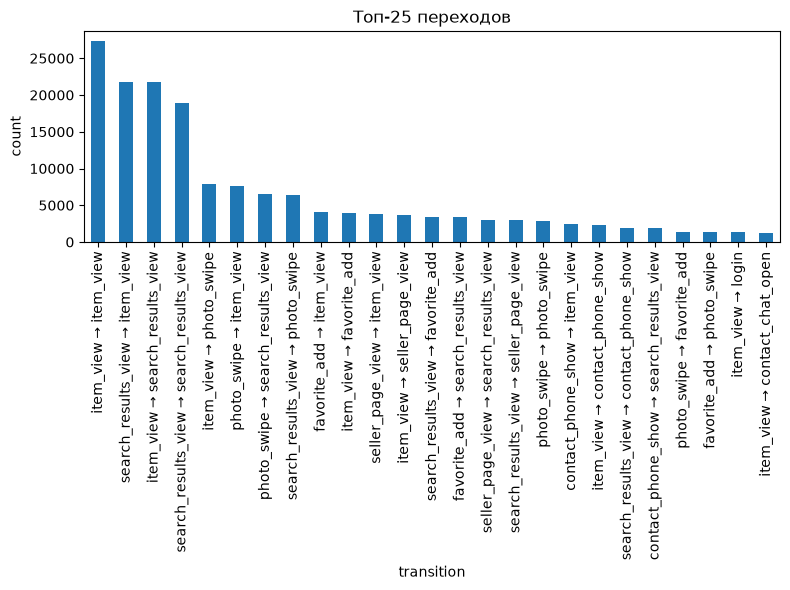

In [7]:
event_mix = (ev_train.merge(train[['cookie_id', 'target']], on='cookie_id')
             .groupby(['target', 'event_name']).size().rename('n').reset_index())
event_mix['share'] = event_mix.n / event_mix.groupby('target').n.transform('sum')
display(
    event_mix.pivot(index='event_name', columns='target', values='share')
    .fillna(0).sort_values(1, ascending=False).round(4)
)

p = (event_mix.pivot(index='event_name', columns='target', values='share')
     .fillna(0).sort_values(1, ascending=False))

p.plot(kind='bar', figsize=(8, 4))
plt.xlabel('event_name')
plt.ylabel('share')
plt.title('Доля событий по типам')
plt.tight_layout()
plt.show()

mix = pd.crosstab(ev_train.cookie_id, ev_train.event_name, normalize='index')
mix = mix.merge(train[['cookie_id', 'target']], left_index=True, right_on='cookie_id')
mix_cols = [c for c in mix.columns if c not in ['cookie_id', 'target']]
display(mix.groupby('target')[mix_cols].median().T.sort_values(1, ascending=False).head(15).round(4))

m = mix.groupby('target')[mix_cols].median().T.sort_values(1, ascending=False).head(15)

m.plot(kind='bar', figsize=(8, 4))
plt.xlabel('event_name')
plt.ylabel('median share within cookie')
plt.title('Топ-15 событий: медианная доля внутри cookie')
plt.tight_layout()
plt.show()

seq = ev_train.sort_values(['cookie_id', 'event_ts']).copy()
seq['next_event'] = seq.groupby('cookie_id').event_name.shift(-1)
display(
    seq.dropna(subset=['next_event']).groupby(['event_name', 'next_event'])
    .size().sort_values(ascending=False).head(25).to_frame('count')
)
top = (seq.dropna(subset=['next_event'])
       .groupby(['event_name', 'next_event'])
       .size().sort_values(ascending=False).head(25))

top.index = [f'{a} → {b}' for a, b in top.index]

top.plot(kind='bar', figsize=(8, 6))
plt.xlabel('transition')
plt.ylabel('count')
plt.title('Топ-25 переходов')
plt.tight_layout()
plt.show()

## 5. User-agent и платформа

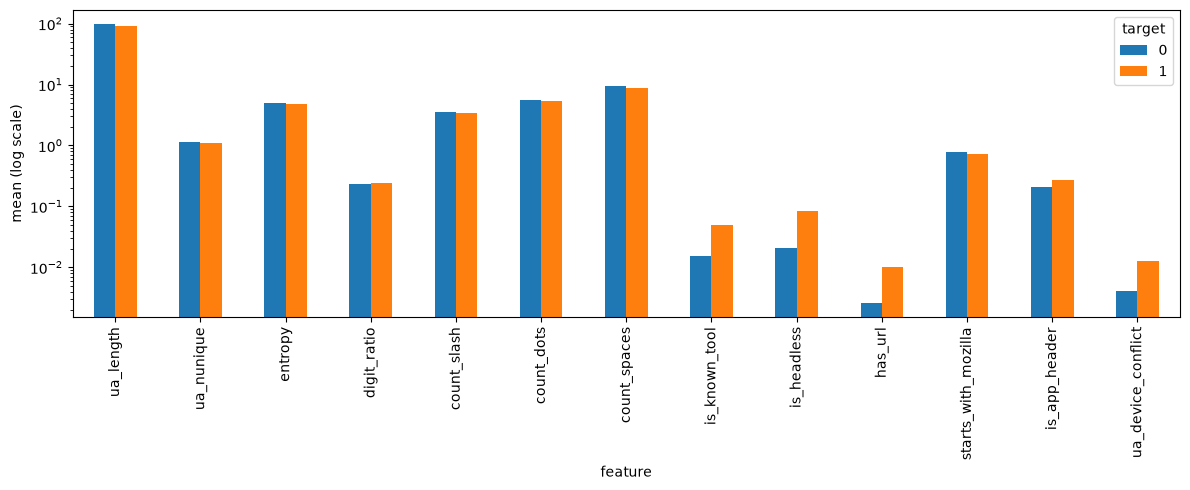

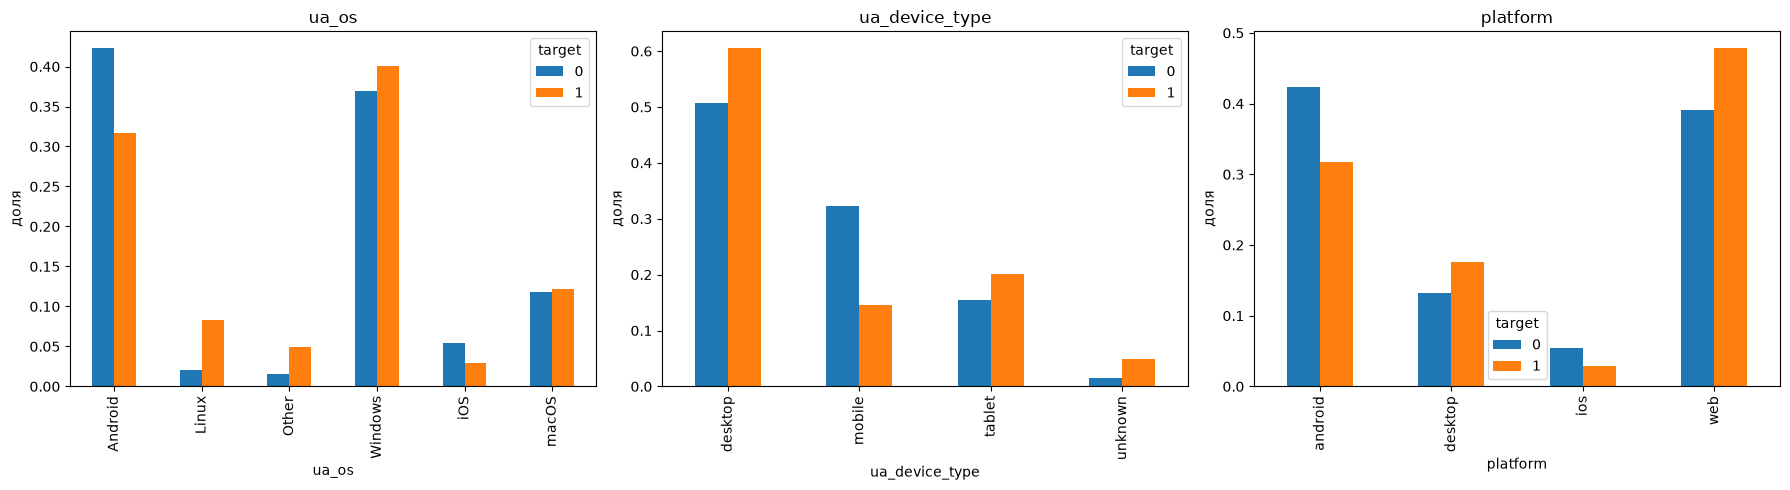

target,0,1,delta
chrome_major_version,77.3418,69.4372,-7.9046
ua_length,98.7528,92.3182,-6.4346
count_spaces,9.5924,8.7255,-0.8669
digit_count,21.8904,21.3629,-0.5275
count_dots,5.6517,5.4609,-0.1908
count_semicolon,1.7804,1.6192,-0.1612
count_slash,3.5762,3.4203,-0.1559
count_open_paren,1.6525,1.5562,-0.0963
entropy,4.9245,4.8583,-0.0662
is_headless,0.0207,0.0834,0.0627


In [8]:
from feature_engineering import add_ua_features
import matplotlib.pyplot as plt
import numpy as np

ua = ev_train[['cookie_id', 'user_agent', 'platform']].copy()
add_ua_features(ua, col='user_agent')

num_cols = [
    'ua_length', 'count_slash', 'count_semicolon', 'count_dots',
    'count_open_paren', 'count_spaces', 'digit_count', 'digit_ratio',
    'entropy', 'is_known_tool', 'is_headless', 'has_url',
    'starts_with_mozilla', 'is_app_header', 'ua_device_conflict',
    'chrome_major_version',
]
cat_cols = ['ua_os', 'ua_device_type']

agg = {c: 'mean' for c in num_cols}
agg['user_agent'] = 'nunique'
ua_cookie = ua.groupby('cookie_id').agg(agg).rename(columns={'user_agent': 'ua_nunique'}).reset_index()

ua_cookie = ua_cookie.merge(
    ua.groupby('cookie_id')[cat_cols].agg(lambda x: x.mode().iloc[0] if len(x) else 'Other').reset_index(),
    on='cookie_id', how='left'
)

ua_cookie = ua_cookie.merge(train[['cookie_id', 'target']], on='cookie_id')

plot_cols = ['ua_length', 'ua_nunique', 'entropy', 'digit_ratio',
             'count_slash', 'count_dots', 'count_spaces', 'is_known_tool',
             'is_headless', 'has_url', 'starts_with_mozilla', 'is_app_header', 'ua_device_conflict']

p = ua_cookie.groupby('target')[plot_cols].mean().T

p.plot(kind='bar', figsize=(12, 5), logy=True)
plt.ylabel('mean (log scale)')
plt.xlabel('feature')
plt.tight_layout()
plt.show()

ua_cookie = ua_cookie.merge(
    ev_train[['cookie_id', 'platform']].drop_duplicates('cookie_id'), on='cookie_id', how='left')

ua_cookie['platform'] = ua_cookie['platform'].str.lower().replace('iphone', 'ios').fillna('')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols + ['platform']):
    pd.crosstab(ua_cookie[col], ua_cookie['target'], normalize='columns').plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_ylabel('доля')
plt.tight_layout()
plt.show()

summary = ua_cookie.groupby('target')[num_cols].mean().T.round(4)
summary['delta'] = (summary[1] - summary[0]).round(4)
display(summary.sort_values('delta', key=abs, ascending=False))

## 6. Категории и доля ответов

Ниже ищем категории, которые заметно меняют долю ботов


item_category:


,item_category,cookies,bot_rate,bots
1,bytovaya_tehnika,1632,0.072917,119
7,mebel,1683,0.070113,118
10,rabota,1627,0.068838,112
9,odezhda,1642,0.068819,113
12,uslugi,1659,0.068716,114
3,elektronika,1684,0.067696,114
4,hobbi,1653,0.067151,111
11,telefony,1615,0.066873,108
5,kvartiry_arenda,1641,0.065204,107
14,zhivotnye,1667,0.061788,103


,item_category,cookies,bot_rate,bots
13,zapchasti,1682,0.052913,89
8,noutbuki,1654,0.056227,93
6,kvartiry_prodazha,1623,0.059766,97
0,avtomobili,1710,0.061404,105
2,detskie_tovary,1685,0.061721,104
14,zhivotnye,1667,0.061788,103
5,kvartiry_arenda,1641,0.065204,107
11,telefony,1615,0.066873,108
4,hobbi,1653,0.067151,111
3,elektronika,1684,0.067696,114


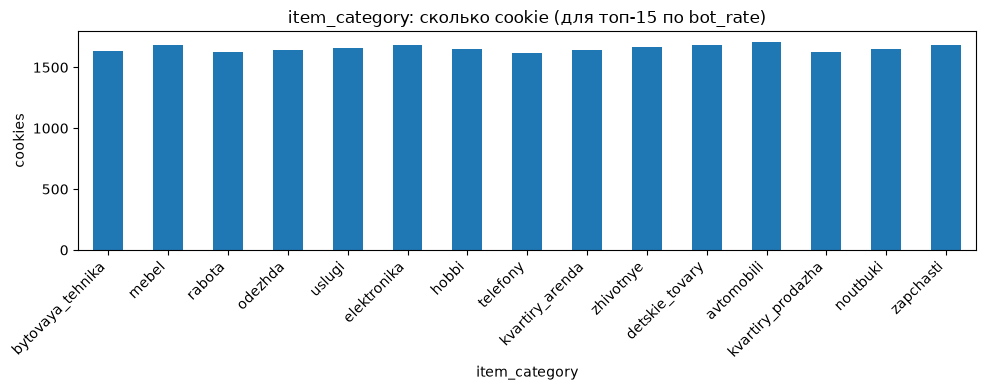


item_location:


,item_location,cookies,bot_rate,bots
22,orenburg,1263,0.158353,200
34,ufa,1335,0.155056,207
35,ulyanovsk,1334,0.153673,205
1,barnaul,1400,0.152143,213
38,voronezh,1308,0.150612,197
19,nizhniy_novgorod,1287,0.149961,193
26,ryazan,1374,0.145560,200
27,samara,1287,0.143745,185
12,kemerovo,1296,0.143519,186
23,penza,1332,0.143393,191


,item_location,cookies,bot_rate,bots
32,tula,1242,0.103060,128
28,sankt-peterburg,5391,0.107958,582
5,ekaterinburg,5328,0.109985,586
18,moskva,5371,0.111897,601
20,novosibirsk,5419,0.113121,613
8,ivanovo,1342,0.116244,156
11,kazan,1315,0.118631,156
25,rostov-na-donu,1377,0.119826,165
6,habarovsk,1259,0.121525,153
10,kaliningrad,1273,0.122545,156


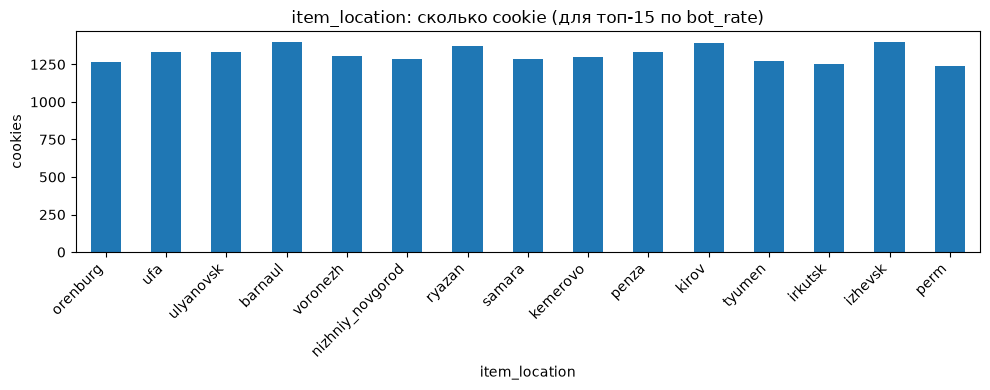


seller_type:


,seller_type,cookies,bot_rate,bots
1,pro,9407,0.090252,849
0,private,10220,0.085127,870


,seller_type,cookies,bot_rate,bots
0,private,10220,0.085127,870
1,pro,9407,0.090252,849


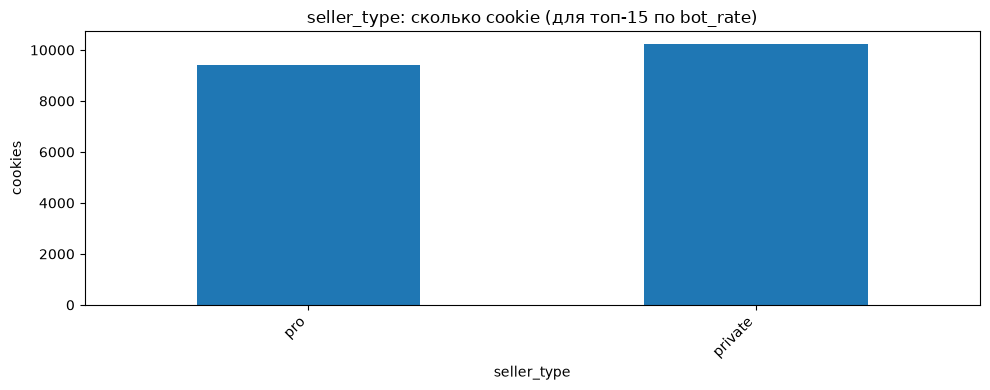


platform:


,platform,cookies,bot_rate,bots
1,desktop,5270,0.107590,567
3,web,5866,0.100239,588
0,android,4595,0.062024,285
2,ios,579,0.044905,26


,platform,cookies,bot_rate,bots
2,ios,579,0.044905,26
0,android,4595,0.062024,285
3,web,5866,0.100239,588
1,desktop,5270,0.107590,567


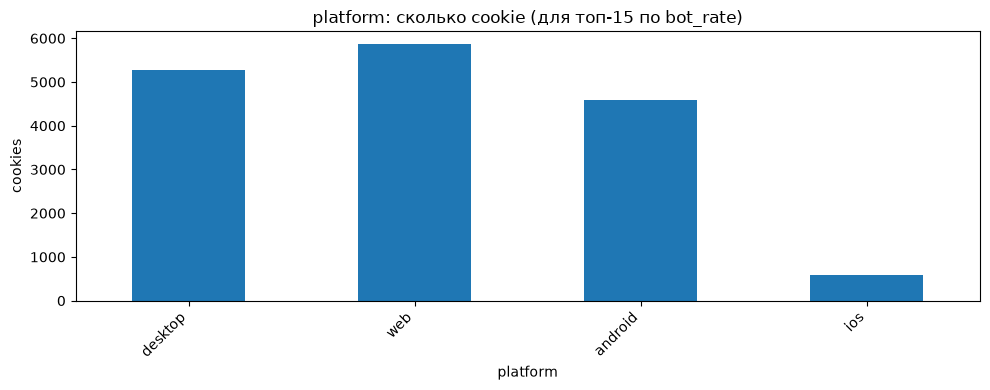

unique_categories                                       \
                   count  mean   std  min  25%  50%  75%  max   
target                                                          
0                10192.0  2.28  1.26  0.0  1.0  2.0  3.0  8.0   
1                  899.0  1.79  0.81  0.0  1.0  2.0  2.0  6.0   

       unique_locations        ...             unique_items                \
                  count  mean  ...   75%   max        count   mean    std   
target                         ...                                          
0               10192.0  5.88  ...   8.0  30.0      10192.0   8.92   9.02   
1                 899.0  9.79  ...  14.0  31.0        899.0  13.78  10.98   

                                    
        min  25%   50%   75%   max  
target                              
0       0.0  3.0   6.0  12.0  80.0  
1       1.0  6.0  10.0  18.0  70.0  

[2 rows x 24 columns]

In [9]:
def category_target_report(df, col, min_cookies=50):
    z = df[['cookie_id', 'target', col]].drop_duplicates(['cookie_id', col]).dropna(subset=[col])
    r = z.groupby(col).agg(cookies=('cookie_id', 'nunique'), bot_rate=('target', 'mean'),
                           bots=('target', 'sum')).reset_index()
    return r[r.cookies >= min_cookies].sort_values(['bot_rate', 'cookies'], ascending=[False, False])


cookie_cat = (ev_train[['cookie_id', 'item_category', 'item_location', 'seller_type', 'platform']]
              .merge(train[['cookie_id', 'target']], on='cookie_id'))
cookie_cat['platform'] = cookie_cat['platform'].str.lower().replace('iphone', 'ios').fillna('')
for col in ['item_category', 'item_location', 'seller_type', 'platform']:
    print(f'\n{col}:')
    r = category_target_report(cookie_cat, col)
    display(r.head(15))
    display(r.sort_values('bot_rate'))
    top = r.head(15)

    top.plot(kind='bar', x=col, y='cookies', figsize=(10, 4), legend=False)
    plt.ylabel('cookies')
    plt.title(f'{col}: сколько cookie (для топ-15 по bot_rate)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

display(basic.groupby('target')[['unique_categories', 'unique_locations', 'unique_items']].describe().round(2))

## 7. Смотрим распределения признаков train vs test


Train/test shapes: (11091, 18) (4909, 18)


,count_train,mean_train,std_train,min_train,25%_train,50%_train,75%_train,max_train,count_test,mean_test,std_test,min_test,25%_test,50%_test,75%_test,max_test
events,11091.0,17.892,17.707,1.000,6.000,12.000,23.000,169.000,4909.0,18.271,18.658,1.000,6.000,12.000,23.000,191.000
unique_events,11091.0,4.615,1.895,1.000,3.000,5.000,6.000,9.000,4909.0,4.630,1.912,1.000,3.000,5.000,6.000,9.000
unique_items,11091.0,9.311,9.288,0.000,3.000,6.000,12.000,80.000,4909.0,9.489,9.642,0.000,3.000,6.000,12.000,91.000
unique_categories,11091.0,2.241,1.235,0.000,1.000,2.000,3.000,8.000,4909.0,2.257,1.241,0.000,1.000,2.000,3.000,8.000
unique_locations,11091.0,6.199,4.887,0.000,3.000,5.000,8.000,31.000,4909.0,6.346,5.053,0.000,3.000,5.000,9.000,32.000
active_hours,11091.0,3.140,2.222,1.000,2.000,3.000,4.000,17.000,4909.0,3.152,2.277,1.000,2.000,3.000,4.000,18.000
gap_mean,10844.0,816.548,847.793,0.000,216.406,633.905,1104.068,9005.000,4805.0,800.221,823.508,0.000,203.105,631.400,1089.643,8972.000
gap_median,10844.0,209.479,738.166,0.000,34.000,56.000,97.000,9005.000,4805.0,199.648,701.671,0.000,32.500,55.000,94.000,8972.000
gap_min,10844.0,57.339,477.703,0.000,0.000,5.000,16.000,9005.000,4805.0,58.574,465.354,0.000,0.000,5.000,15.000,8972.000
gap_std,10454.0,1615.371,1119.393,0.000,678.454,1701.050,2349.744,6356.183,4613.0,1609.189,1110.260,0.000,656.344,1708.507,2349.427,6460.128


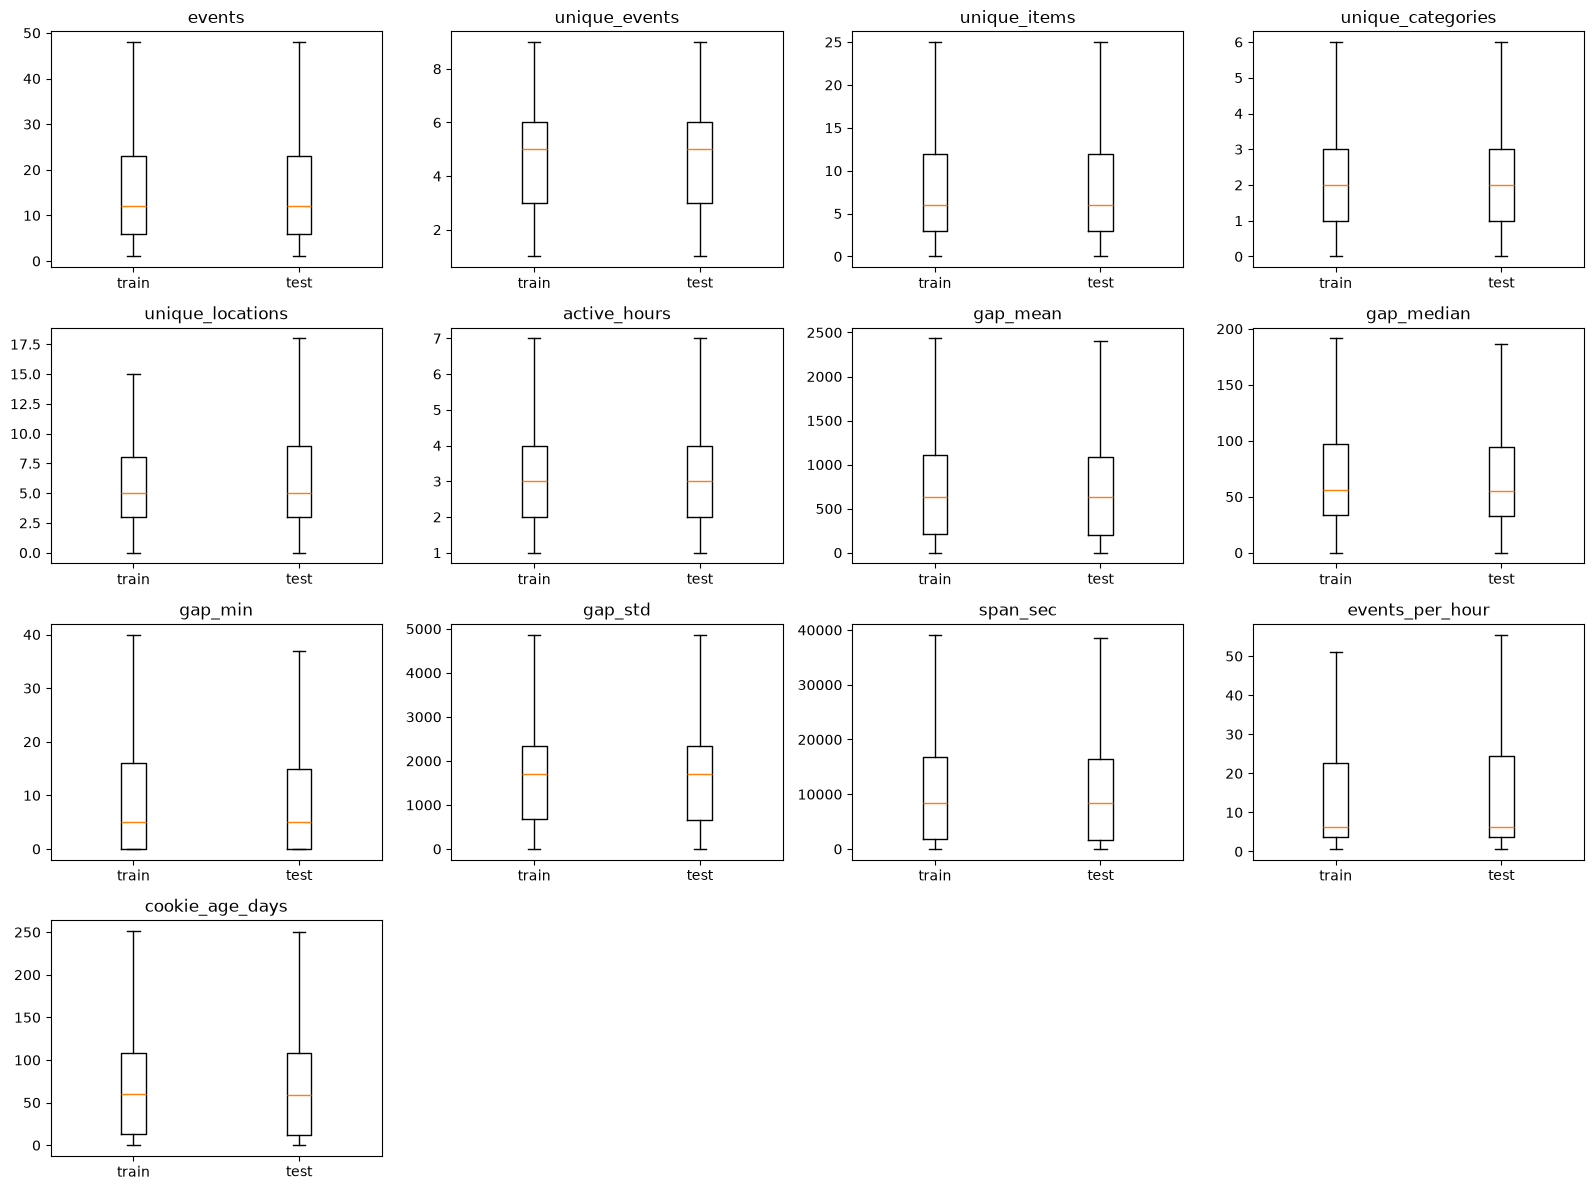

In [10]:
def make_distribution_features(ev, meta):
    out = cookie_basic_agg(ev).set_index('cookie_id')
    meta_small = meta.set_index('cookie_id').copy()
    out['cookie_age_days'] = (meta_small.window_start_ts - meta_small.cookie_created_at).dt.total_seconds() / 86400
    out['window_day'] = meta_small.window_start_ts.dt.day
    return out.reset_index()


train_dist = make_distribution_features(ev_train, train).assign(split='train')
test_dist = make_distribution_features(ev_test, test).assign(split='test')
numeric_features = [
    'events', 'unique_events', 'unique_items', 'unique_categories',
    'unique_locations', 'active_hours', 'gap_mean', 'gap_median',
    'gap_min', 'gap_std', 'span_sec', 'events_per_hour', 'cookie_age_days'
]
print('Train/test shapes:', train_dist.shape, test_dist.shape)
display(pd.concat([train_dist[numeric_features].describe().T.add_suffix('_train'),
                   test_dist[numeric_features].describe().T.add_suffix('_test')], axis=1).round(3))

fig, axes = plt.subplots(4, 4, figsize=(16, 3 * 4))
axes = axes.ravel()

for ax, col in zip(axes, numeric_features):
    data = [train_dist[col].dropna(), test_dist[col].dropna()]
    ax.boxplot(data, tick_labels=['train', 'test'], showfliers=False)
    ax.set_title(col)

for ax in axes[13:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

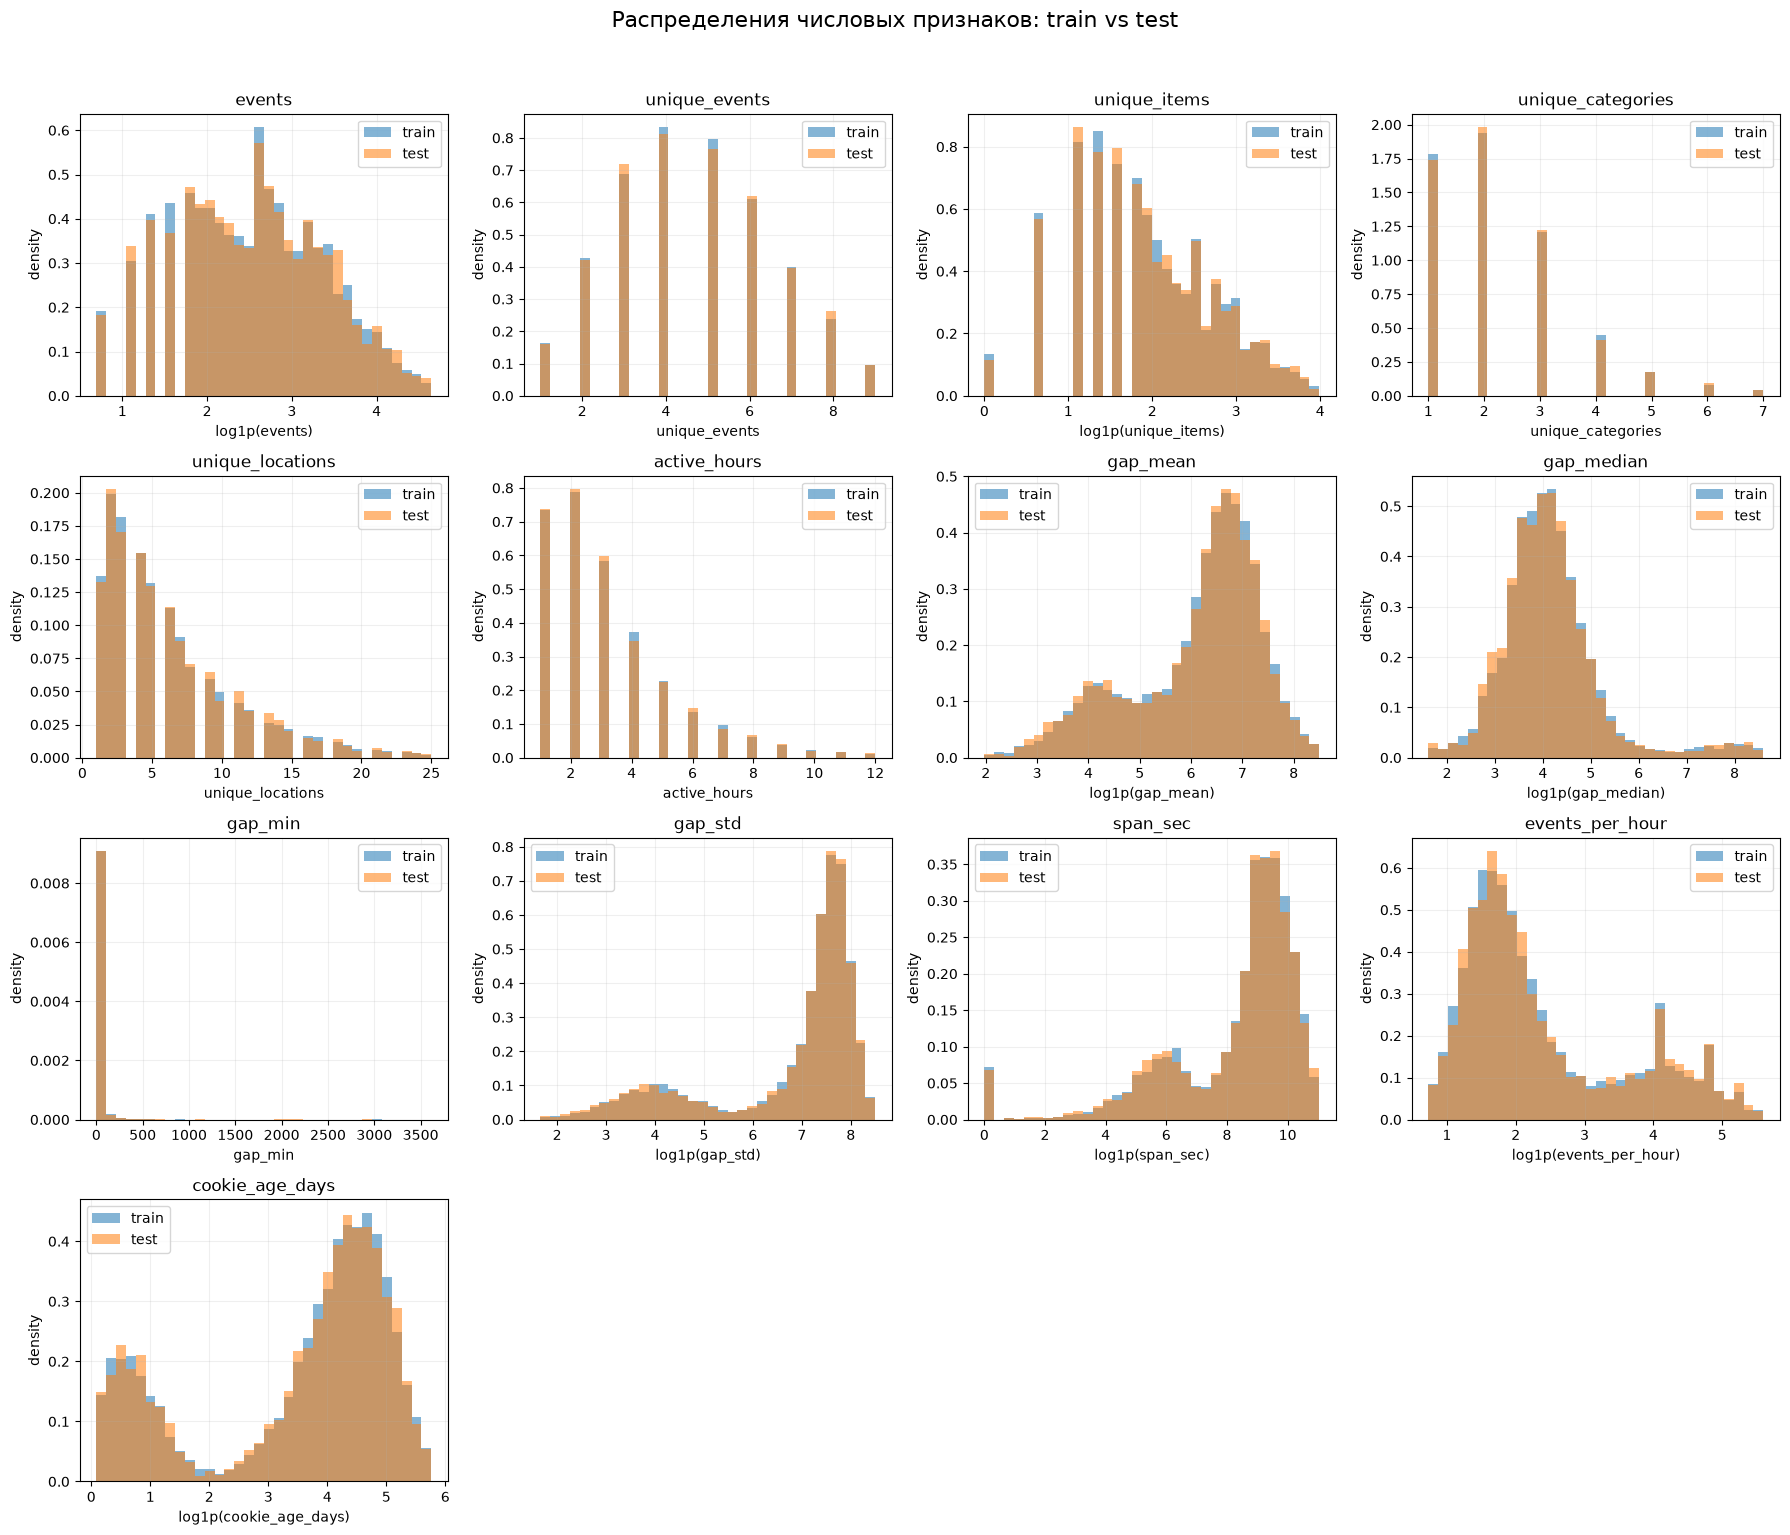

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(18, 15))
axes = axes.ravel()
log_cols = {'events', 'unique_items', 'span_sec', 'events_per_hour',
            'gap_mean', 'gap_median', 'gap_std', 'cookie_age_days'}

for ax, col in zip(axes, numeric_features):
    a = train_dist[col].replace([np.inf, -np.inf], np.nan).dropna()
    b = test_dist[col].replace([np.inf, -np.inf], np.nan).dropna()
    if col in log_cols:
        a, b = np.log1p(a.clip(lower=0)), np.log1p(b.clip(lower=0))
        xlabel = f'log1p({col})'
    else:
        xlabel = col

    lo, hi = np.nanpercentile(pd.concat([a, b]), [0.5, 99.5])
    bins = np.linspace(lo, hi, 35) if hi > lo else 10
    ax.hist(a, bins=bins, density=True, alpha=0.55, label='train')
    ax.hist(b, bins=bins, density=True, alpha=0.55, label='test')
    ax.set(title=col, xlabel=xlabel, ylabel='density')
    ax.grid(alpha=0.2)
    ax.legend()

for ax in axes[len(numeric_features):]:
    ax.axis('off')

plt.suptitle('Распределения числовых признаков: train vs test', y=1.02, fontsize=16)
plt.tight_layout()

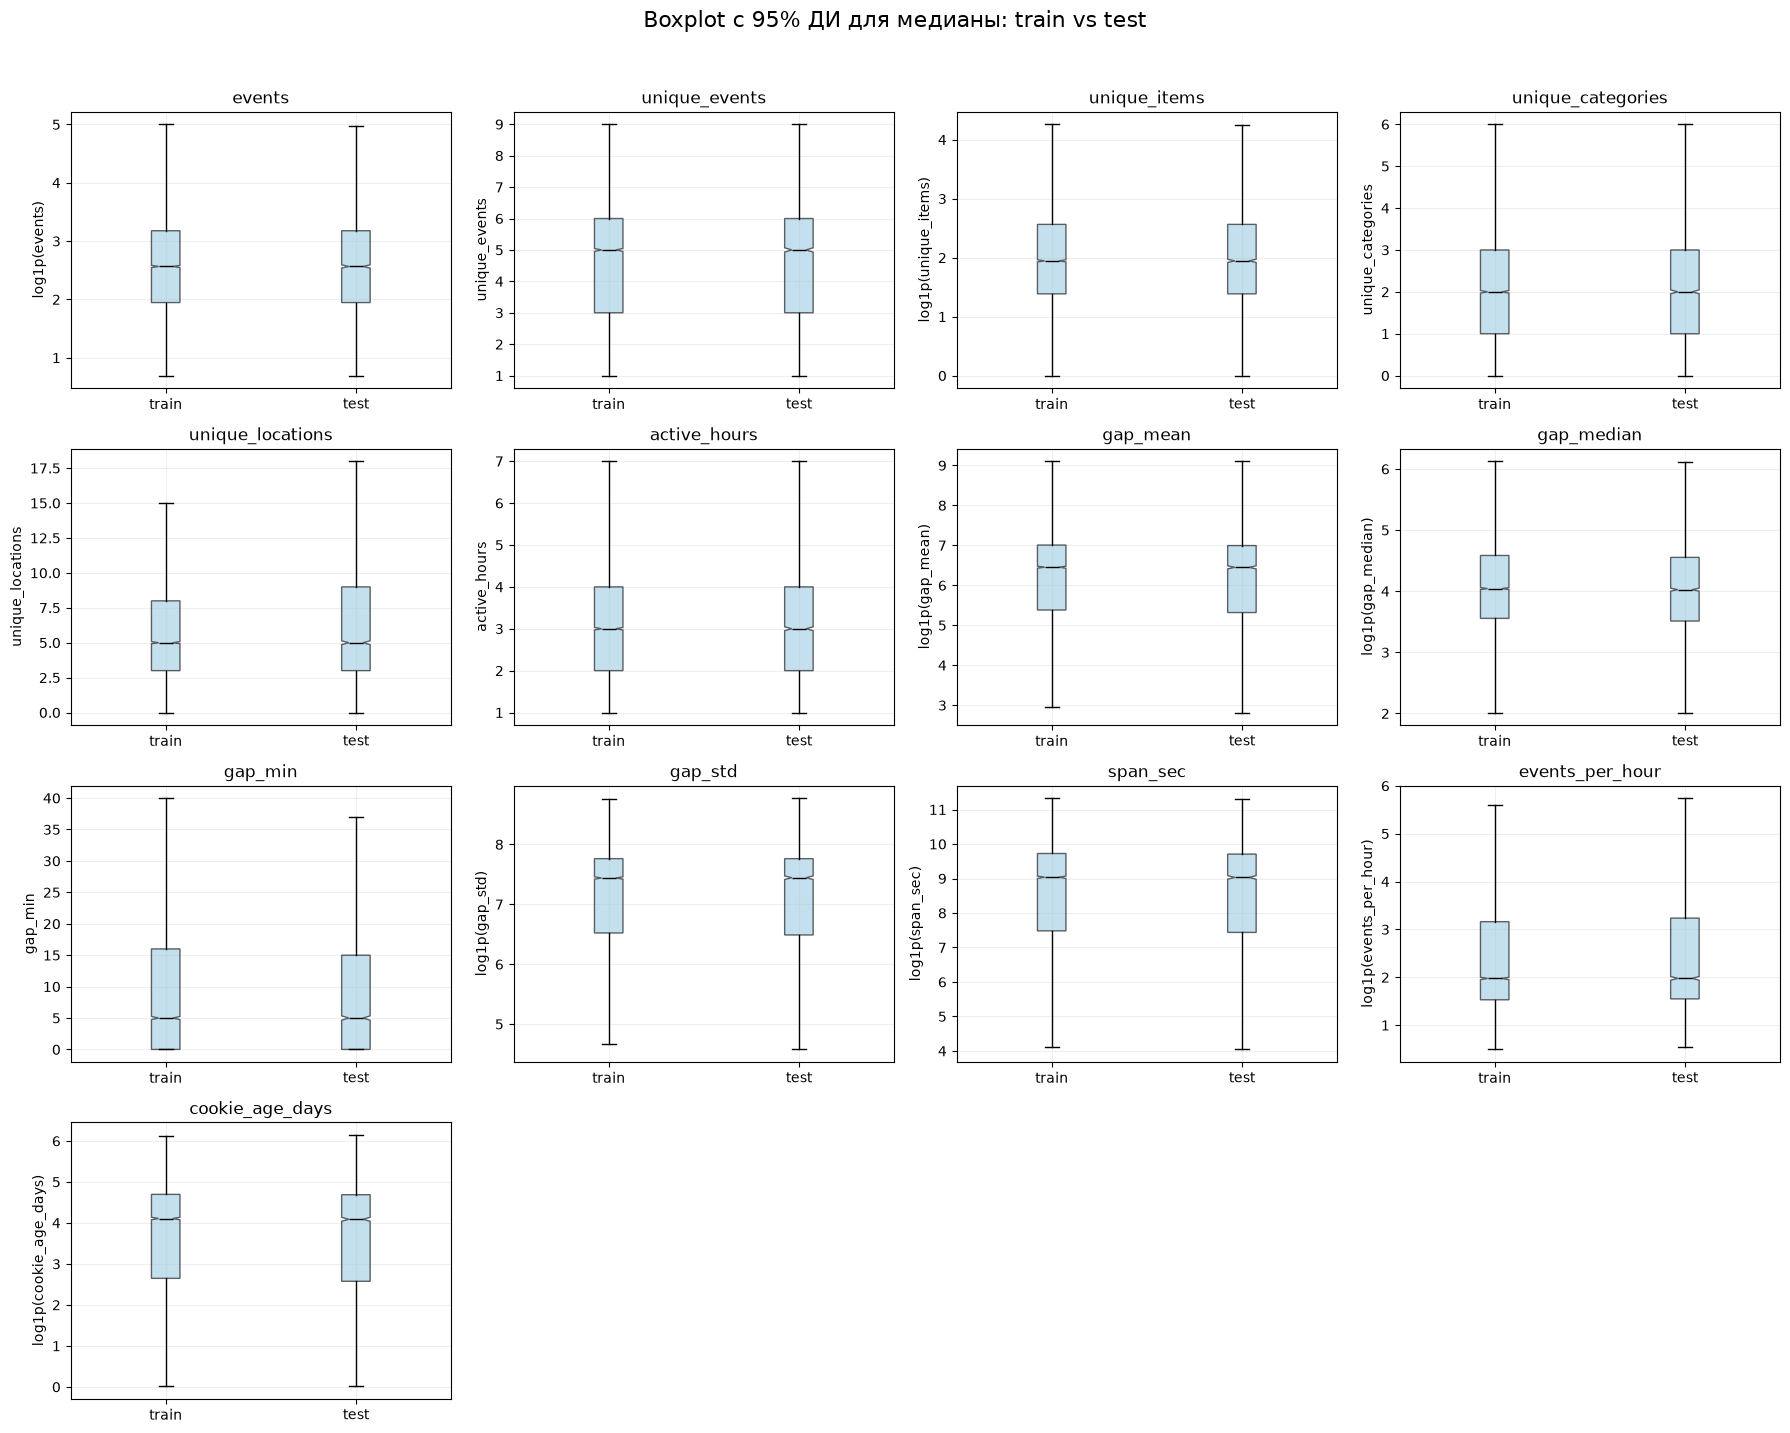

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.ravel()

log_cols = {'events', 'unique_items', 'span_sec', 'events_per_hour',
            'gap_mean', 'gap_median', 'gap_std', 'cookie_age_days'}

for ax, col in zip(axes, numeric_features):
    a = train_dist[col].replace([np.inf, -np.inf], np.nan).clip(lower=0).dropna()
    b = test_dist[col].replace([np.inf, -np.inf], np.nan).clip(lower=0).dropna()

    if col in log_cols:
        a, b = np.log1p(a), np.log1p(b)
        ylabel = f'log1p({col})'
    else:
        ylabel = col

    ax.boxplot([a, b], notch=True, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor='#9ecae1', alpha=0.6),
               medianprops=dict(color='black'))
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['train', 'test'])

    ax.set_title(col)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)

for ax in axes[len(numeric_features):]:
    ax.axis('off')

plt.suptitle('Boxplot с 95% ДИ для медианы: train vs test', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

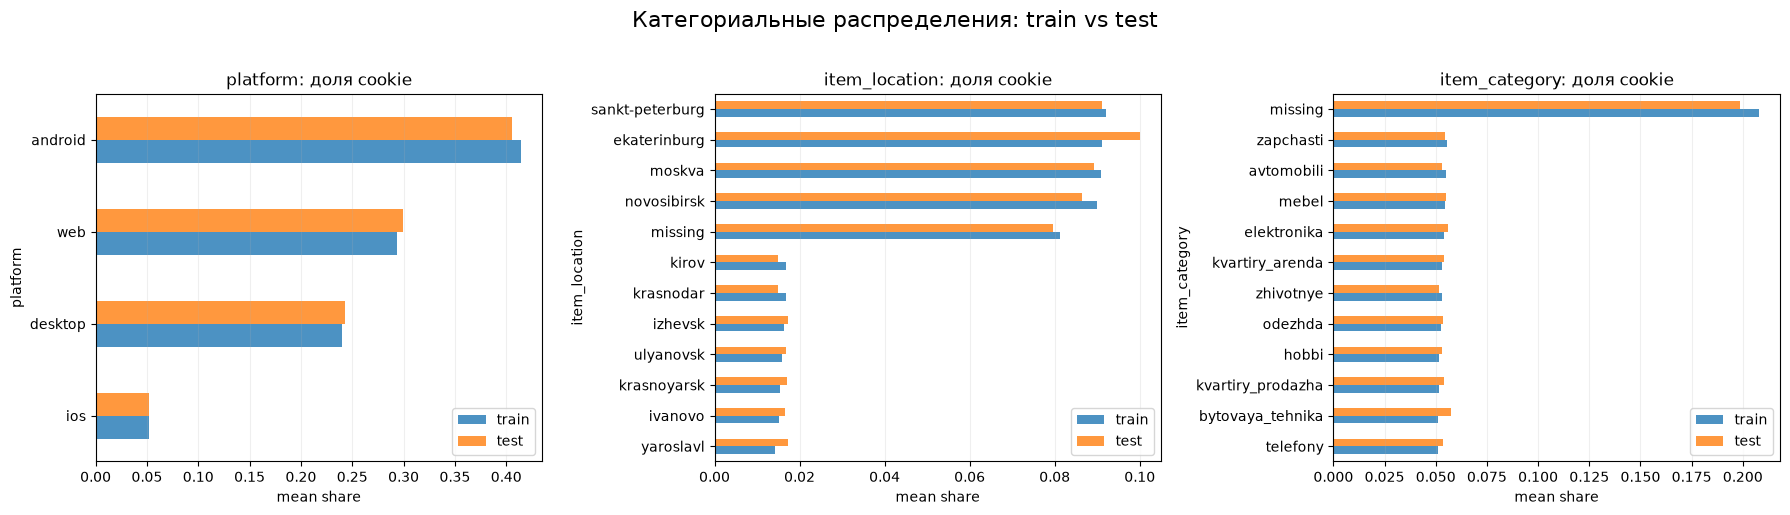

In [13]:
def cookie_category_shares(ev, meta, col):
    z = ev[['cookie_id', col]].copy()
    if col == 'platform':
        z[col] = z[col].astype('string').str.lower().replace({'iphone': 'ios'})
    z[col] = z[col].fillna('missing')
    z = z.drop_duplicates(['cookie_id', col])
    z = z.merge(meta[['cookie_id']], on='cookie_id', how='right')
    return pd.crosstab(z.cookie_id, z[col], normalize='index').mean().sort_values(ascending=False)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['platform', 'item_location', 'item_category']):
    comp = pd.concat([
        cookie_category_shares(ev_train, train, col).rename('train'),
        cookie_category_shares(ev_test, test, col).rename('test'),
    ], axis=1).fillna(0)

    top = comp.max(axis=1).sort_values(ascending=False).head(12).index
    comp.loc[top].sort_values('train').plot.barh(ax=ax, color=['C0', 'C1'], alpha=0.8)

    ax.set(title=f'{col}: доля cookie', xlabel='mean share')
    ax.grid(axis='x', alpha=0.2)

plt.suptitle('Категориальные распределения: train vs test', y=1.02, fontsize=16)
plt.tight_layout()

## 8. События активности cookie


In [14]:
def event_activity_features(ev, meta):
    x = ev.sort_values(['cookie_id', 'event_ts']).copy()
    x['gap_sec'] = x.groupby('cookie_id').event_ts.diff().dt.total_seconds()
    activity = x.groupby('cookie_id').agg(
        event_count=('eid', 'size'),
        unique_event_types=('event_name', 'nunique'),
        unique_items=('item_id', 'nunique'),
        unique_queries=('search_query', 'nunique'),
        unique_categories=('item_category', 'nunique'),
        first_event_ts=('event_ts', 'min'),
        last_event_ts=('event_ts', 'max'),
        median_gap_sec=('gap_sec', 'median'),
        mean_gap_sec=('gap_sec', 'mean'),
        min_gap_sec=('gap_sec', 'min'),
        max_gap_sec=('gap_sec', 'max'),
    )
    activity['active_span_hours'] = (activity.last_event_ts - activity.first_event_ts).dt.total_seconds() / 3600
    activity['events_per_active_hour'] = activity.event_count / activity.active_span_hours.clip(lower=1 / 60)
    activity['events_per_window_hour'] = activity.event_count / 24
    activity['repeated_item_rate'] = 1 - activity.unique_items / activity.event_count
    activity['repeated_event_rate'] = 1 - activity.unique_event_types / activity.event_count
    return activity.reset_index()


activity_train = event_activity_features(ev_train, train).merge(train[['cookie_id', 'target']], on='cookie_id')
activity_test = event_activity_features(ev_test, test)
activity_cols = ['event_count', 'unique_event_types', 'unique_items', 'unique_queries',
                 'active_span_hours', 'events_per_active_hour', 'events_per_window_hour',
                 'median_gap_sec', 'mean_gap_sec', 'repeated_item_rate', 'repeated_event_rate']
display(activity_train.groupby('target')[activity_cols].agg(['mean', 'median']).T.round(3))

activity_compare = pd.concat([
    activity_train[activity_cols].describe().T.add_suffix('_train'),
    activity_test[activity_cols].describe().T.add_suffix('_test')
], axis=1)
display(activity_compare.round(3))

target                               0        1
event_count            mean     16.869   29.485
                       median   12.000   20.000
unique_event_types     mean      4.598    4.803
                       median    4.000    5.000
unique_items           mean      8.917   13.780
                       median    6.000   10.000
unique_queries         mean      3.790    4.759
                       median    3.000    4.000
active_span_hours      mean      3.228    3.356
                       median    2.313    2.526
events_per_active_hour mean     24.522   39.372
                       median    6.026    8.940
events_per_window_hour mean      0.703    1.229
                       median    0.500    0.833
median_gap_sec         mean    219.330   99.974
                       median   59.000   25.000
mean_gap_sec           mean    839.433  562.149
                       median  657.294  425.407
repeated_item_rate     mean      0.469    0.477
                       median    0.486    0.500
repeated_event_rate    mean      0.570    0.718
                       median    0.625    0.769

,count_train,mean_train,std_train,min_train,25%_train,50%_train,75%_train,max_train,count_test,mean_test,std_test,min_test,25%_test,50%_test,75%_test,max_test
event_count,11091.0,17.892,17.707,1.000,6.000,12.000,23.000,169.000,4909.0,18.271,18.658,1.000,6.000,12.000,23.000,191.000
unique_event_types,11091.0,4.615,1.895,1.000,3.000,5.000,6.000,9.000,4909.0,4.630,1.912,1.000,3.000,5.000,6.000,9.000
unique_items,11091.0,9.311,9.288,0.000,3.000,6.000,12.000,80.000,4909.0,9.489,9.642,0.000,3.000,6.000,12.000,91.000
unique_queries,11091.0,3.868,3.207,0.000,2.000,3.000,5.000,29.000,4909.0,3.932,3.305,0.000,2.000,3.000,5.000,25.000
active_span_hours,11091.0,3.239,3.407,0.000,0.493,2.336,4.651,23.191,4909.0,3.247,3.470,0.000,0.471,2.323,4.572,22.393
events_per_active_hour,11091.0,25.726,46.961,0.637,3.618,6.213,22.615,714.706,4909.0,27.066,50.983,0.706,3.704,6.227,24.451,855.944
events_per_window_hour,11091.0,0.745,0.738,0.042,0.250,0.500,0.958,7.042,4909.0,0.761,0.777,0.042,0.250,0.500,0.958,7.958
median_gap_sec,10844.0,209.479,738.166,0.000,34.000,56.000,97.000,9005.000,4805.0,199.648,701.671,0.000,32.500,55.000,94.000,8972.000
mean_gap_sec,10844.0,816.548,847.793,0.000,216.406,633.905,1104.068,9005.000,4805.0,800.221,823.508,0.000,203.105,631.400,1089.643,8972.000
repeated_item_rate,11091.0,0.470,0.169,0.000,0.385,0.490,0.571,1.000,4909.0,0.466,0.168,0.000,0.378,0.481,0.567,1.000


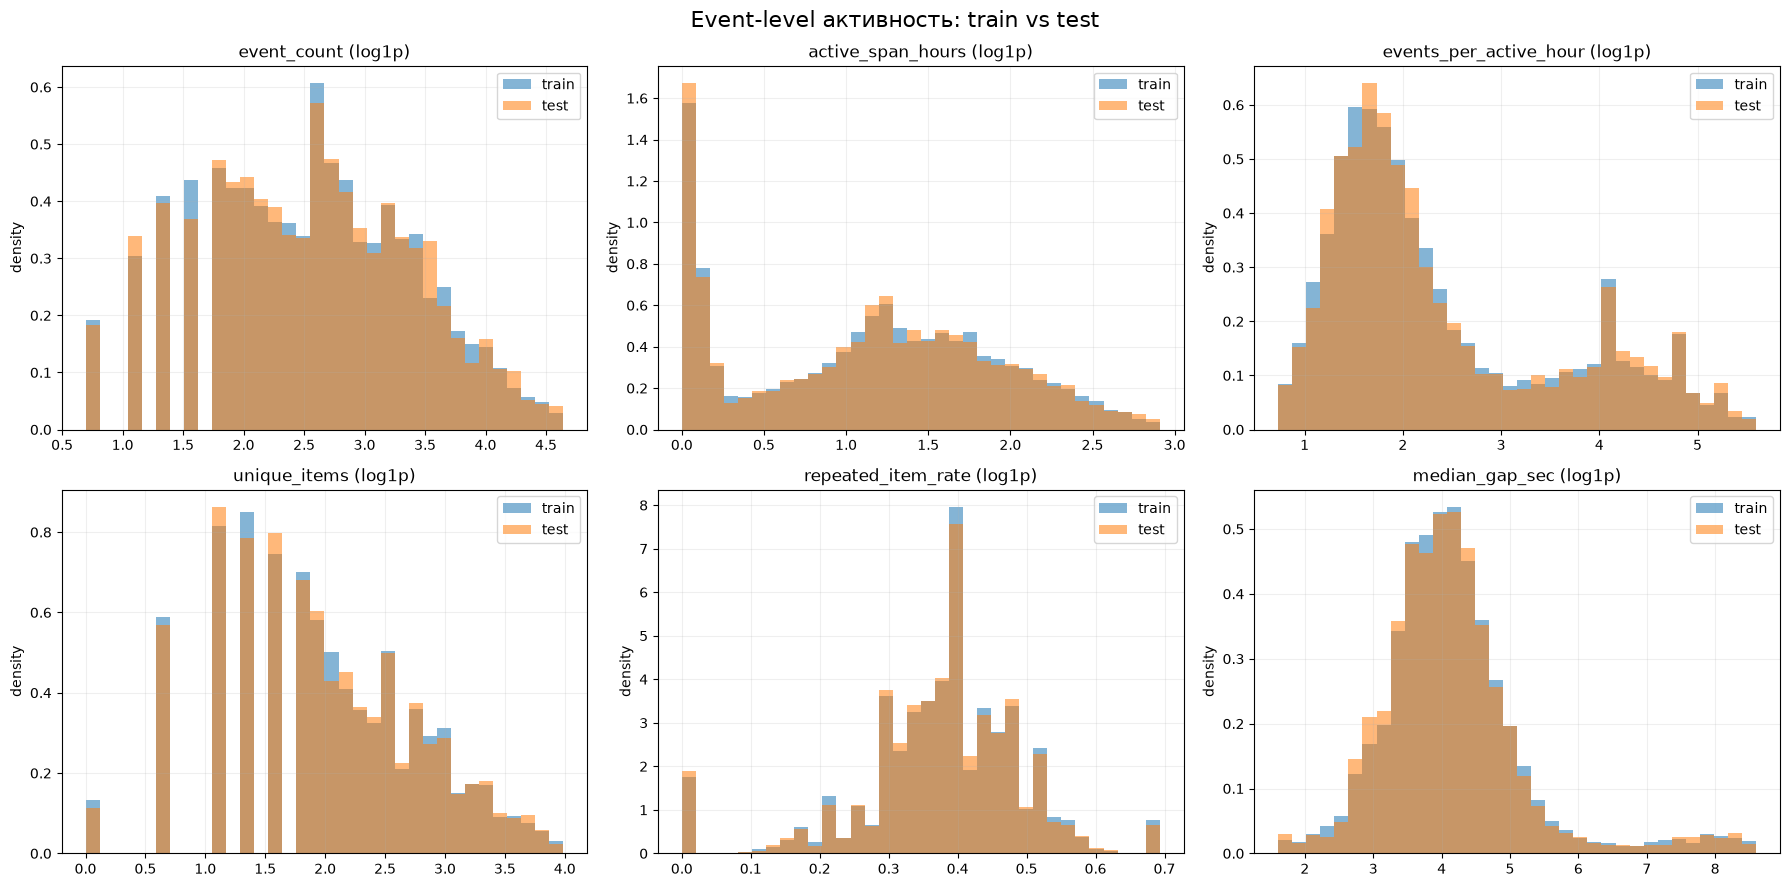

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
plot_cols = ['event_count', 'active_span_hours', 'events_per_active_hour',
             'unique_items', 'repeated_item_rate', 'median_gap_sec']
for ax, col in zip(axes.ravel(), plot_cols):
    tr = activity_train[col].replace([np.inf, -np.inf], np.nan).dropna()
    te = activity_test[col].replace([np.inf, -np.inf], np.nan).dropna()
    tr_plot = np.log1p(tr.clip(lower=0))
    te_plot = np.log1p(te.clip(lower=0))
    lo, hi = np.nanpercentile(pd.concat([tr_plot, te_plot]), [0.5, 99.5])
    bins = np.linspace(lo, hi, 35)
    ax.hist(tr_plot, bins=bins, density=True, alpha=0.55, label='train', color='C0')
    ax.hist(te_plot, bins=bins, density=True, alpha=0.55, label='test', color='C1')
    ax.set_title(f'{col} (log1p)')
    ax.set_ylabel('density')
    ax.grid(alpha=0.2)
    ax.legend()
plt.suptitle('Event-level активность: train vs test', fontsize=16)
plt.tight_layout()

target,0,1
item_view,0.3643,0.4249
search_results_view,0.3085,0.3313
photo_swipe,0.1270,0.0782
seller_page_view,0.0529,0.0610
contact_phone_show,0.0307,0.0333
favorite_add,0.0687,0.0330
contact_chat_open,0.0166,0.0181
contact_message_sent,0.0081,0.0104
login,0.0232,0.0098


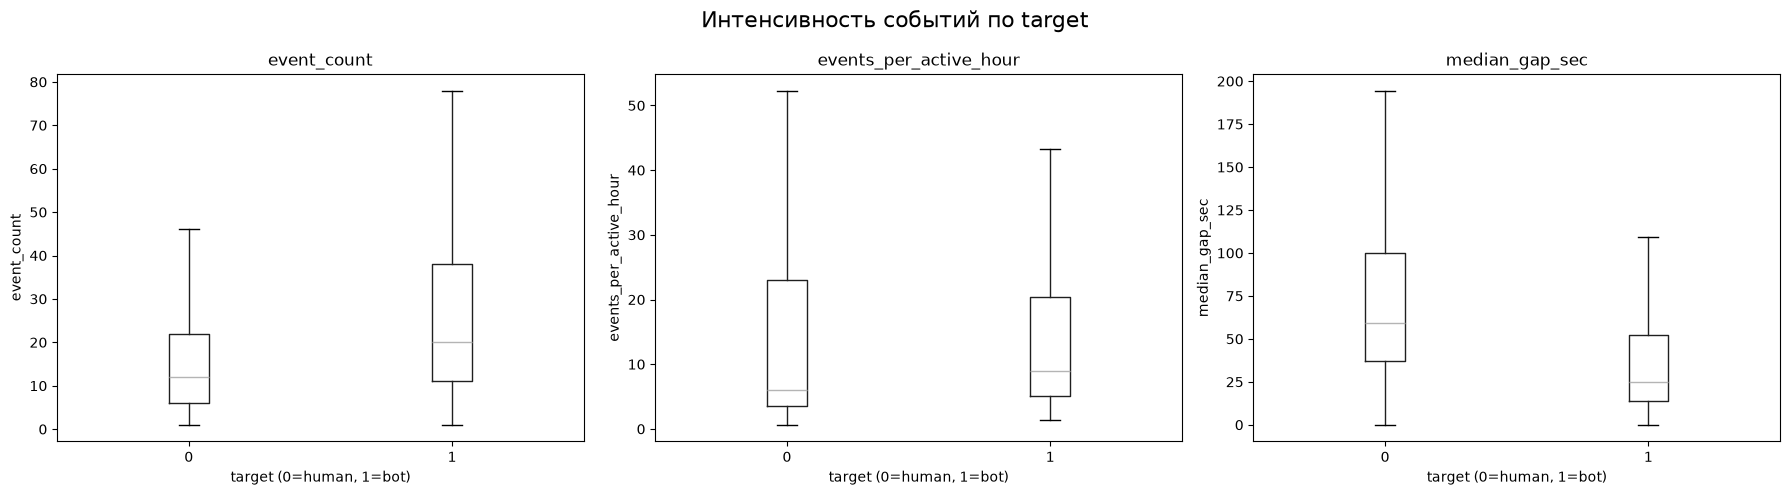

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['event_count', 'events_per_active_hour', 'median_gap_sec']):
    activity_train.boxplot(column=col, by='target', ax=ax, showfliers=False, grid=False)
    ax.set_title(col)
    ax.set_xlabel('target (0=human, 1=bot)')
    ax.set_ylabel(col)
plt.suptitle('Интенсивность событий по target', fontsize=16)
plt.tight_layout()

event_per_cookie = pd.crosstab(ev_train.cookie_id, ev_train.event_name, normalize='index')
event_per_cookie = event_per_cookie.merge(train[['cookie_id', 'target']], left_index=True, right_on='cookie_id')
event_share = event_per_cookie.groupby('target').mean(numeric_only=True).T.sort_values(1, ascending=False)
display(event_share.round(4))

## 10. Карта ошибок модели

In [17]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

PREDICTIONS_PATH = Path('artifacts/validation_predictions.csv')
predictions_path = PREDICTIONS_PATH

pred = pd.read_csv(predictions_path)
if 'target' not in pred:
    pred = pred.merge(train[['cookie_id', 'target']], on='cookie_id', how='left')
score_col = 'ensemble_score'
pred = pred[['cookie_id', 'target', score_col]].dropna().rename(columns={score_col: 'score'})

order = np.argsort(-pred.score.to_numpy(), kind='mergesort')
y_sorted = pred.target.to_numpy()[order].astype(int)
score_sorted = pred.score.to_numpy()[order]
precision = np.cumsum(y_sorted) / np.arange(1, len(pred) + 1)
recall = np.cumsum(y_sorted) / y_sorted.sum()
group_ends = np.r_[score_sorted[1:] != score_sorted[:-1], True]
valid_points = np.flatnonzero(group_ends & (recall >= 0.70))
best_index = valid_points[np.argmax(precision[valid_points])]
threshold = score_sorted[best_index]
pred['pred_bot'] = pred.score >= threshold
pred['error_type'] = np.select(
    [(pred.target.eq(1) & ~pred.pred_bot), (pred.target.eq(0) & pred.pred_bot)],
    ['FN: bot missed', 'FP: human flagged'],
    default=np.where(pred.target.eq(1), 'TP: bot caught', 'TN: human passed'),
)

diagnostic = pred.merge(basic, on=['cookie_id', 'target'], how='left')
diagnostic_features = ['events', 'unique_events', 'unique_items', 'unique_categories',
                       'unique_locations', 'active_hours', 'gap_mean', 'gap_median',
                       'gap_min', 'gap_std', 'span_sec', 'events_per_hour']
for col in diagnostic_features:
    diagnostic[col] = np.log1p(diagnostic[col].clip(lower=0).fillna(0))
feature_matrix = StandardScaler().fit_transform(diagnostic[diagnostic_features])
print(f'predictions: {predictions_path}, score: {score_col}, n={len(diagnostic)}, threshold={threshold:.5f}')
display(diagnostic.groupby('error_type')[diagnostic_features].median().T.round(2))

predictions: artifacts/validation_predictions.csv, score: ensemble_score, n=1951, threshold=0.89739


error_type,FN: bot missed,FP: human flagged,TN: human passed,TP: bot caught
events,2.71,3.09,2.56,3.14
unique_events,1.61,1.79,1.61,1.79
unique_items,2.14,2.40,1.95,2.56
unique_categories,1.10,1.10,1.10,1.10
unique_locations,1.95,2.20,1.79,2.35
active_hours,1.39,1.10,1.39,1.39
gap_mean,6.67,5.97,6.45,5.90
gap_median,3.84,3.22,4.06,3.06
gap_min,1.39,1.10,1.61,1.39
gap_std,7.54,7.17,7.43,7.06


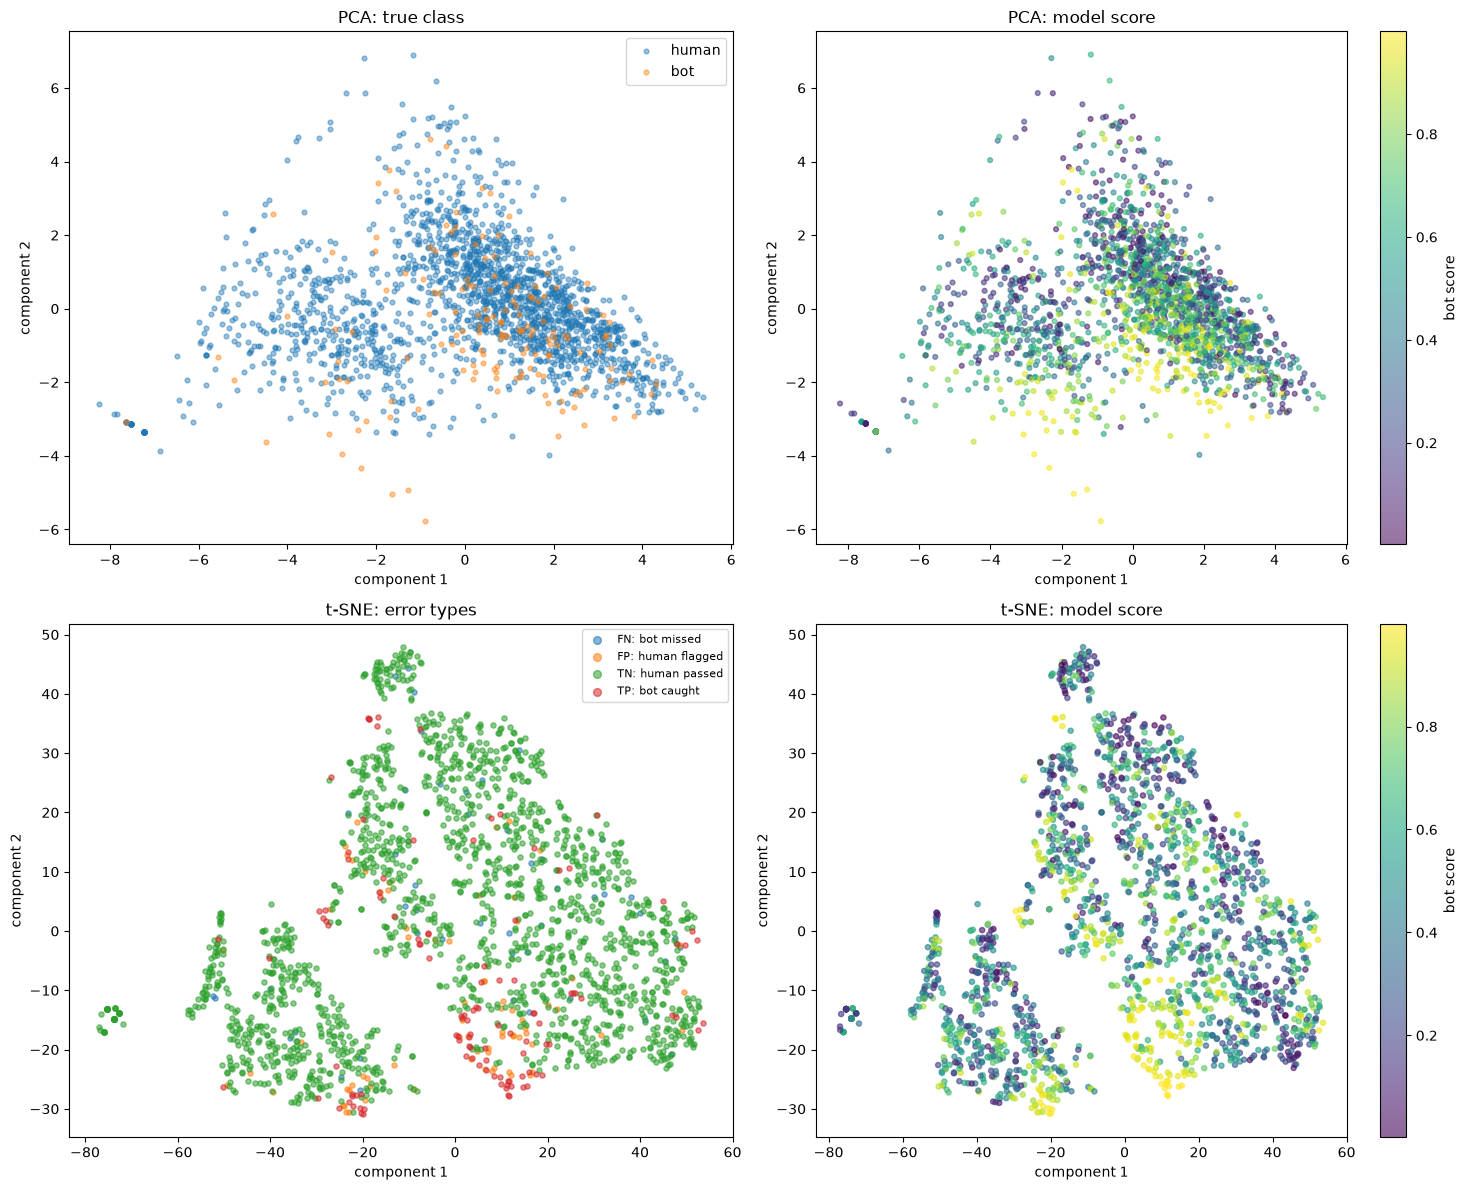

,cookies
error_type,
TN: human passed,1718
TP: bot caught,112
FP: human flagged,73
FN: bot missed,48


In [18]:
pca_xy = PCA(n_components=2, random_state=42).fit_transform(feature_matrix)
diagnostic['pca_1'], diagnostic['pca_2'] = pca_xy[:, 0], pca_xy[:, 1]

tsne_n = min(2500, len(diagnostic))
tsne_index = diagnostic.sample(tsne_n, random_state=42).index
perplexity = min(35, max(5, (tsne_n - 1) // 3))
tsne_xy = TSNE(n_components=2, perplexity=perplexity, learning_rate='auto',
               init='pca', random_state=42).fit_transform(feature_matrix[diagnostic.index.get_indexer(tsne_index)])
diagnostic.loc[tsne_index, 'tsne_1'] = tsne_xy[:, 0]
diagnostic.loc[tsne_index, 'tsne_2'] = tsne_xy[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for target, color, label in [(0, 'tab:blue', 'human'), (1, 'tab:orange', 'bot')]:
    part = diagnostic[diagnostic.target.eq(target)]
    axes[0, 0].scatter(part.pca_1, part.pca_2, s=12, alpha=.45, c=color, label=label)
axes[0, 0].set_title('PCA: true class')
axes[0, 0].legend()
scatter = axes[0, 1].scatter(diagnostic.pca_1, diagnostic.pca_2, c=diagnostic.score, s=12, alpha=.55, cmap='viridis')
axes[0, 1].set_title('PCA: model score')
fig.colorbar(scatter, ax=axes[0, 1], label='bot score')
for label, part in diagnostic.loc[tsne_index].groupby('error_type', observed=True):
    axes[1, 0].scatter(part.tsne_1, part.tsne_2, s=14, alpha=.55, label=label)
axes[1, 0].set_title('t-SNE: error types')
axes[1, 0].legend(markerscale=1.5, fontsize=8)
scatter = axes[1, 1].scatter(diagnostic.loc[tsne_index, 'tsne_1'], diagnostic.loc[tsne_index, 'tsne_2'],
                             c=diagnostic.loc[tsne_index, 'score'], s=14, alpha=.6, cmap='viridis')
axes[1, 1].set_title('t-SNE: model score')
fig.colorbar(scatter, ax=axes[1, 1], label='bot score')
for ax in axes.ravel():
    ax.set_xlabel('component 1')
    ax.set_ylabel('component 2')
plt.tight_layout()
plt.show()

display(diagnostic.error_type.value_counts().rename('cookies').to_frame())